In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
from sklearn.datasets import make_regression
X, y =  make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)

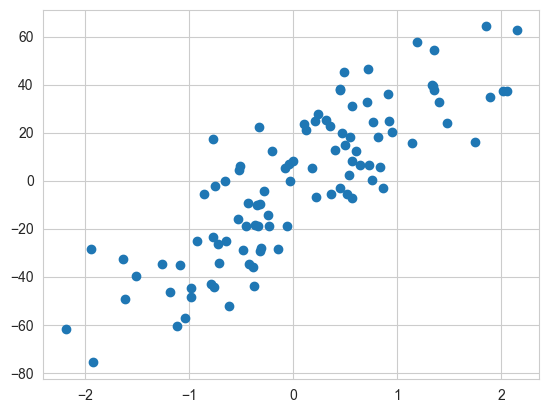

In [19]:
plt.scatter(X,y)

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train

array([[ 1.3501879 ],
       [-0.53032741],
       [-0.33861825],
       [-0.27813452],
       [-0.14521133],
       [ 0.45315861],
       [-1.51284512],
       [ 1.84961257],
       [-0.42989708],
       [ 0.71097479],
       [ 0.39724133],
       [-0.6209797 ],
       [-0.98027432],
       [-0.48137142],
       [-0.38445769],
       [ 0.86121137],
       [-0.76403397],
       [-1.92415945],
       [-1.18541881],
       [ 0.63988397],
       [ 1.13833305],
       [-2.18711527],
       [ 0.18494595],
       [-0.31485808],
       [-0.32212366],
       [ 1.74924179],
       [ 0.10126979],
       [-1.63909341],
       [ 1.89274222],
       [-0.23242587],
       [-0.2073497 ],
       [ 0.95283061],
       [ 0.3595323 ],
       [-1.08718159],
       [-0.72099967],
       [ 1.350306  ],
       [-0.24332625],
       [ 0.56465429],
       [ 0.21745166],
       [ 0.49087183],
       [ 0.72916547],
       [-0.75745323],
       [ 0.50113729],
       [ 0.45181234],
       [ 1.47868574],
       [ 0

In [21]:
class BatchGradientDescentRegressor:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.coef = None
        self.intercept = None
    
    def fit(self,X_train, y_train):
        no_of_rows = X_train.shape[0]
        no_of_cols = X_train.shape[1]
        
        # 1. Initialize Intercept and Coef
        self.intercept = 0
        self.coef = np.random.random(no_of_cols)
        
        for epoch in range(self.epochs):
            y_hat = self.intercept + np.dot(X_train, self.coef)
            
            # 2. Calculate Gradient
            dL_by_dB0 = (-2 * np.sum(y_train - y_hat)) / no_of_rows
            dL_by_dB1 = (-2 * np.dot(y_train - y_hat, X_train)) / no_of_rows
            
            # 3. Update Intercept and Coef
            self.intercept -= (self.learning_rate * dL_by_dB0)
            self.coef -= (self.learning_rate * dL_by_dB1)
    
    def predict(self, X_test):
        return np.dot(X_test, self.coef) + self.intercept
    

In [22]:
bGd = BatchGradientDescentRegressor(learning_rate=0.5,epochs=500)

In [23]:
bGd.fit(X_train, y_train)

In [24]:
bGd.intercept, bGd.coef

(np.float64(-2.713072566924103), array([28.16404017]))

In [25]:
y_pred = bGd.predict(X_test)
y_pred

array([ 20.68858776, -24.53062886,  13.1389669 ,  23.26386508,
        30.82199856,  13.12248871, -28.85874316,  11.77250597,
        54.0436877 , -22.77687179, -48.20103812,  17.62038031,
        18.516034  , -38.24499309,   7.10915317,   3.98596515,
        12.2797131 , -30.43101636,   3.13941648,  18.85807699])

In [26]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.6186926408914154

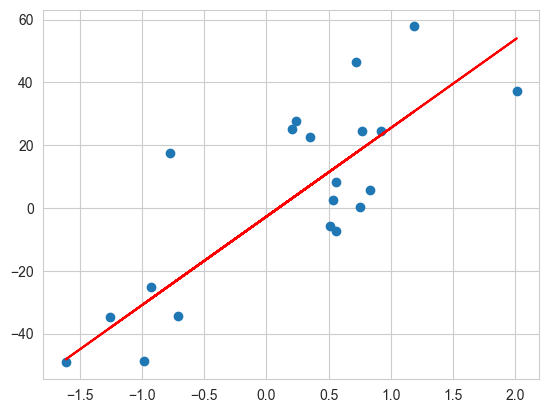

In [30]:
plt.scatter(X_test,y_test)
plt.plot(X_test, y_pred, color='r')